In [1]:
%pip install h5netcdf

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
import pandas as pd

pd.read_parquet(
    r"C:\Users\floris\Desktop\MSC\thesis_msc\data\yearly_aggregated_FH_FX\year=1953\month=04\knmi_fh_1953_04.parquet"
)

,time,station,stationname,lat,lon,height,FH,FX
0,1953-04-01 01:00:00,0-20000-0-06210,VALKENBURG VK,52.1703,4.4294,-0.20,NaN,NaN
1,1953-04-01 01:00:00,0-20000-0-06235,DE KOOY VK,52.9269,4.7811,0.57,6.7,NaN
2,1953-04-01 01:00:00,0-20000-0-06240,AMSTERDAM/SCHIPHOL AP,52.3172,4.7897,-3.87,NaN,NaN
3,1953-04-01 01:00:00,0-20000-0-06260,DE BILT AWS,52.0989,5.1797,1.90,6.7,10.8
4,1953-04-01 01:00:00,0-20000-0-06265,SOESTERBERG,52.1289,5.2731,14.00,NaN,NaN
...,...,...,...,...,...,...,...,...
10075,1953-05-01 00:00:00,0-20000-0-06310,VLISSINGEN AWS,51.4414,3.5958,8.03,3.1,NaN
10076,1953-05-01 00:00:00,0-20000-0-06350,GILZE RIJEN,51.5650,4.9353,11.95,NaN,NaN
10077,1953-05-01 00:00:00,0-20000-0-06370,EINDHOVEN AP,51.4497,5.3769,20.69,NaN,NaN
10078,1953-05-01 00:00:00,0-20000-0-06375,VOLKEL,51.6586,5.7067,19.85,NaN,NaN


Using station: P11-B
Station ID from metadata: 06203
Total hourly rows for P11-B: 144,552
Number of observed hourly FX values: 141,983
Number of missing hourly FX values: 2,569
Hourly missing percentage: 1.78%
Total months: 199
Months with at least one observed FX value: 199
Months with all FX values missing: 0


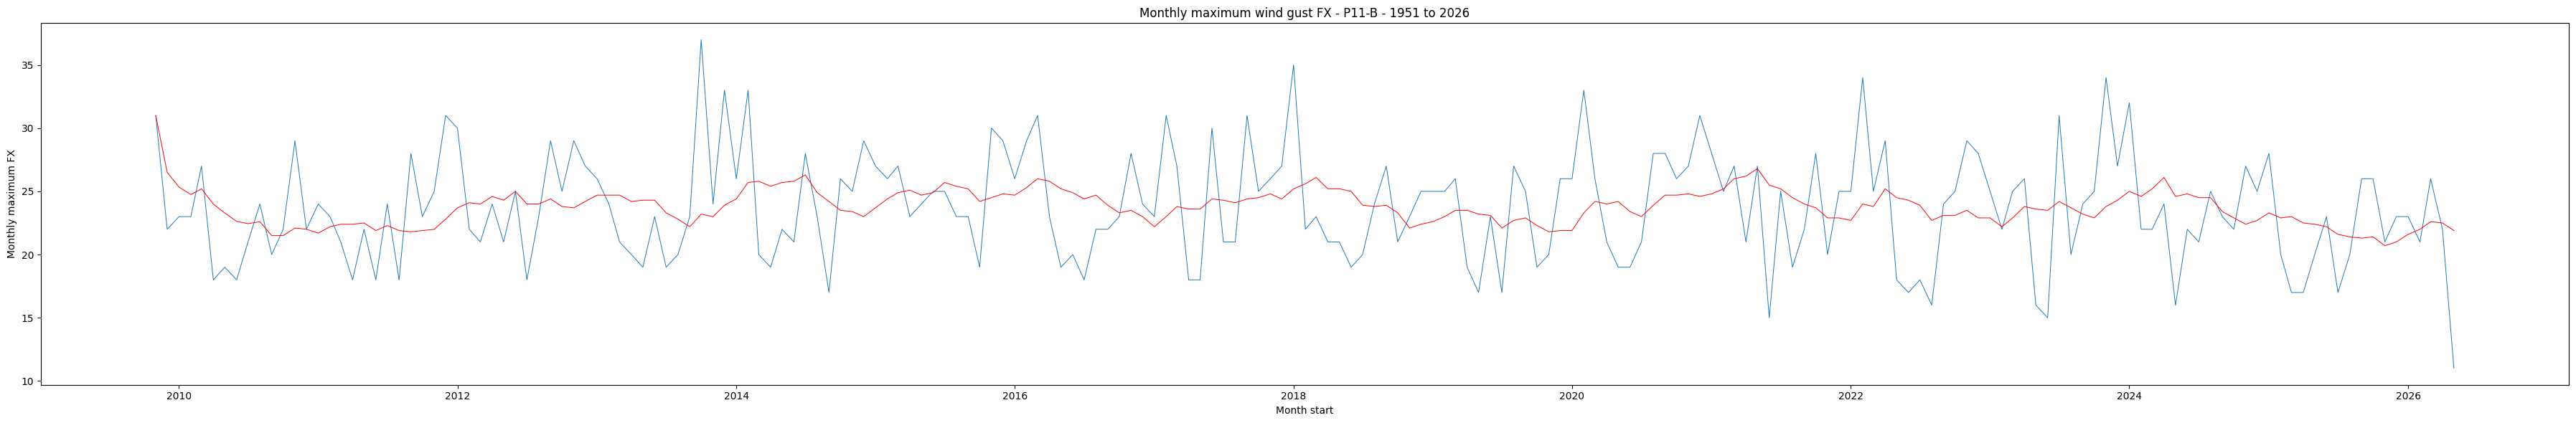

In [58]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------
PARQUET_ROOT = Path(r"C:\Users\floris\Desktop\MSC\thesis_msc\data\yearly_aggregated_FH_FX")

STATION_METADATA_PATH = Path(r"C:\Users\floris\Desktop\MSC\thesis_msc\data\station_metadata.csv")

TARGET_STATIONNAME = "P11-B"


# ---------------------------------------------------------------------
# Read metadata
# ---------------------------------------------------------------------
meta = pd.read_csv(
    STATION_METADATA_PATH,
    dtype={"station_id": str},
)

meta = meta.rename(columns={"station_id": "station"})

schiphol_matches = meta.loc[
    meta["stationname"].eq(TARGET_STATIONNAME),
    ["station", "stationname"],
].drop_duplicates()

if schiphol_matches.empty:
    raise ValueError(f"Station not found in metadata: {TARGET_STATIONNAME}")

station_id = schiphol_matches["station"].iloc[0]

print(f"Using station: {TARGET_STATIONNAME}")
print(f"Station ID from metadata: {station_id}")


# ---------------------------------------------------------------------
# Read parquet files
# ---------------------------------------------------------------------
parquet_files = sorted(PARQUET_ROOT.glob("year=*/month=*/*.parquet"))

if not parquet_files:
    raise FileNotFoundError(f"No parquet files found under {PARQUET_ROOT}")

df = pd.read_parquet(
    parquet_files,
    columns=["time", "station", "FX"],
)

df["time"] = pd.to_datetime(df["time"], errors="coerce")
df["station"] = df["station"].astype(str)


# ---------------------------------------------------------------------
# Filter Schiphol
# ---------------------------------------------------------------------
station_candidates = [
    station_id,
    f"0-20000-0-{station_id}",
]

schiphol = df.loc[
    df["station"].isin(station_candidates) & (df["time"].dt.year >= 1951) & (df["time"].dt.year <= 2026),
    ["time", "station", "FX"],
].sort_values("time")


# ---------------------------------------------------------------------
# Count hourly observations and missing values
# ---------------------------------------------------------------------
total_hourly_rows = len(schiphol)
hourly_missing = int(schiphol["FX"].isna().sum())
hourly_observed = int(schiphol["FX"].notna().sum())

print(f"Total hourly rows for {TARGET_STATIONNAME}: {total_hourly_rows:,}")
print(f"Number of observed hourly FX values: {hourly_observed:,}")
print(f"Number of missing hourly FX values: {hourly_missing:,}")

if total_hourly_rows:
    print(f"Hourly missing percentage: {hourly_missing / total_hourly_rows:.2%}")
else:
    raise ValueError("No rows found for this station. Check station code format.")


# ---------------------------------------------------------------------
# Monthly maxima, ignoring NaNs
# ---------------------------------------------------------------------
monthly_max = (
    schiphol.set_index("time")
    .sort_index()
    .resample("MS", label="left", closed="left")
    .agg(
        monthly_max_FX=("FX", "max"),
        n_hourly_rows=("FX", "size"),
        n_observed=("FX", "count"),
        n_missing=("FX", lambda x: x.isna().sum()),
    )
    .reset_index()
    .rename(columns={"time": "month_start"})
)

monthly_max["coverage"] = monthly_max["n_observed"] / monthly_max["n_hourly_rows"]

total_months = len(monthly_max)
months_with_observation = int(monthly_max["monthly_max_FX"].notna().sum())
months_all_missing = int(monthly_max["monthly_max_FX"].isna().sum())

print(f"Total months: {total_months:,}")
print(f"Months with at least one observed FX value: {months_with_observation:,}")
print(f"Months with all FX values missing: {months_all_missing:,}")

# add a moving average column for better visualization
monthly_max["monthly_max_FX_MA3"] = monthly_max["monthly_max_FX"].rolling(window=10, min_periods=1).mean()

# ---------------------------------------------------------------------
# Plot monthly maxima, ignoring all-missing months
# ---------------------------------------------------------------------
plot_df = monthly_max.dropna(subset=["monthly_max_FX"])

plt.figure(figsize=(36, 6))
plt.plot(plot_df["month_start"], plot_df["monthly_max_FX"], linewidth=0.7)
plt.plot(plot_df["month_start"], plot_df["monthly_max_FX_MA3"], linewidth=0.7, color="red")
plt.title(f"Monthly maximum wind gust FX - {TARGET_STATIONNAME} - 1951 to 2026")
plt.xlabel("Month start")
plt.ylabel("Monthly maximum FX")
plt.grid(False)
plt.tight_layout()
plt.show()

Fitted GEV parameters: c=0.1473, loc=22.8057, scale=4.2623


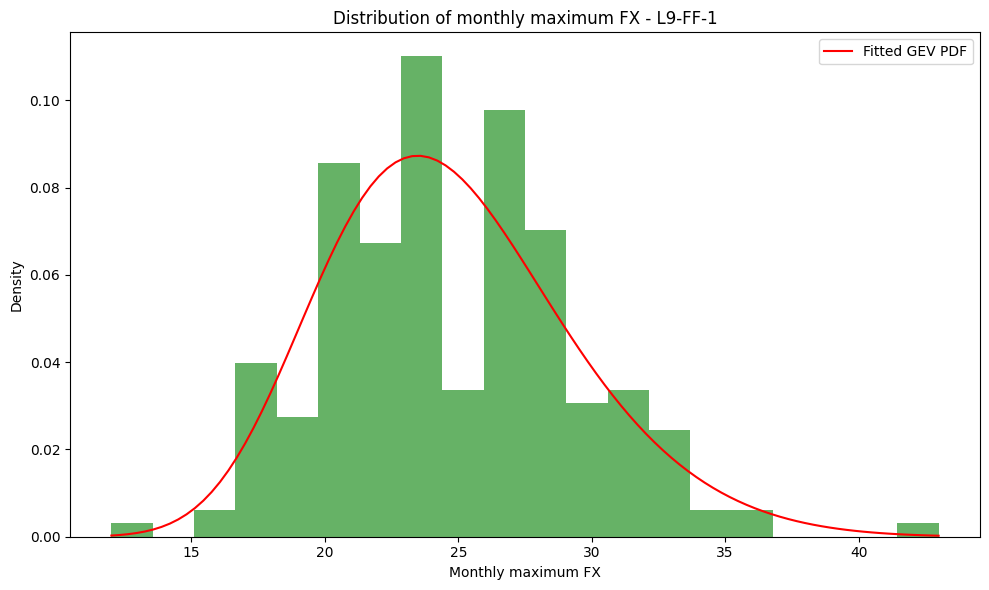

In [54]:
# fit a extreme value distribution to the monthly maxima, ignoring NaNs
from scipy.stats import genextreme

monthly_max_no_na = monthly_max.dropna(subset=["monthly_max_FX"])
c, loc, scale = genextreme.fit(monthly_max_no_na["monthly_max_FX"])
print(f"Fitted GEV parameters: c={c:.4f}, loc={loc:.4f}, scale={scale:.4f}")

# plot the distribution and the fitted GEV PDF
import numpy as np

x = np.linspace(monthly_max_no_na["monthly_max_FX"].min(), monthly_max_no_na["monthly_max_FX"].max(), 100)
pdf_fitted = genextreme.pdf(x, c, loc=loc, scale=scale)
plt.figure(figsize=(10, 6))
plt.hist(monthly_max_no_na["monthly_max_FX"], bins=20, density=True, alpha=0.6, color="g")
plt.plot(x, pdf_fitted, "r-", label="Fitted GEV PDF")
plt.title(f"Distribution of monthly maximum FX - {TARGET_STATIONNAME}")
plt.xlabel("Monthly maximum FX")
plt.ylabel("Density")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

In [55]:
from scipy.stats import genextreme

c = 0.1073
loc = 14.7995
scale = 2.9527

return_periods_months = [12, 24, 60, 120, 240, 600, 1200]  # 1y, 2y, 5y, 10y, 20y, 50y, 100y

for T in return_periods_months:
    p = 1 - 1 / T
    z = genextreme.ppf(p, c, loc=loc, scale=scale)
    print(f"{T:4d} months ({T/12:5.1f} years): {z:.2f}")

  12 months (  1.0 years): 21.14
  24 months (  2.0 years): 22.71
  60 months (  5.0 years): 24.57
 120 months ( 10.0 years): 25.85
 240 months ( 20.0 years): 27.03
 600 months ( 50.0 years): 28.46
1200 months (100.0 years): 29.46


count    211.000000
mean      24.701422
std        4.633311
min       12.000000
25%       21.500000
50%       24.000000
75%       28.000000
max       43.000000
Name: monthly_max_FX, dtype: float64
Observed max: 43.0


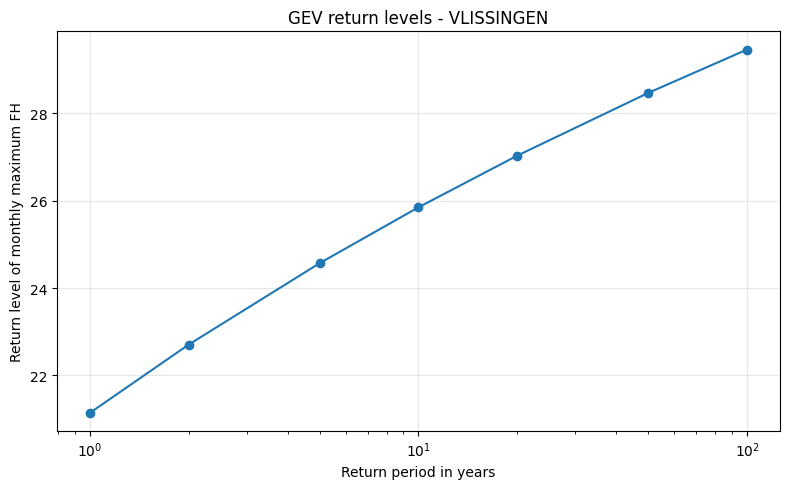

In [56]:
print(monthly_max["monthly_max_FX"].describe())
print("Observed max:", monthly_max["monthly_max_FX"].max())
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme

c = 0.1073
loc = 14.7995
scale = 2.9527

T_years = np.array([1, 2, 5, 10, 20, 50, 100])
T_months = T_years * 12

return_levels = genextreme.ppf(
    1 - 1 / T_months,
    c,
    loc=loc,
    scale=scale,
)

plt.figure(figsize=(8, 5))
plt.plot(T_years, return_levels, marker="o")
plt.xscale("log")
plt.xlabel("Return period in years")
plt.ylabel("Return level of monthly maximum FH")
plt.title("GEV return levels - VLISSINGEN")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Observed max: 37.00
Model CDF at observed max: 1.000000
Implied return period: 4500796.6 months = 375066.4 years


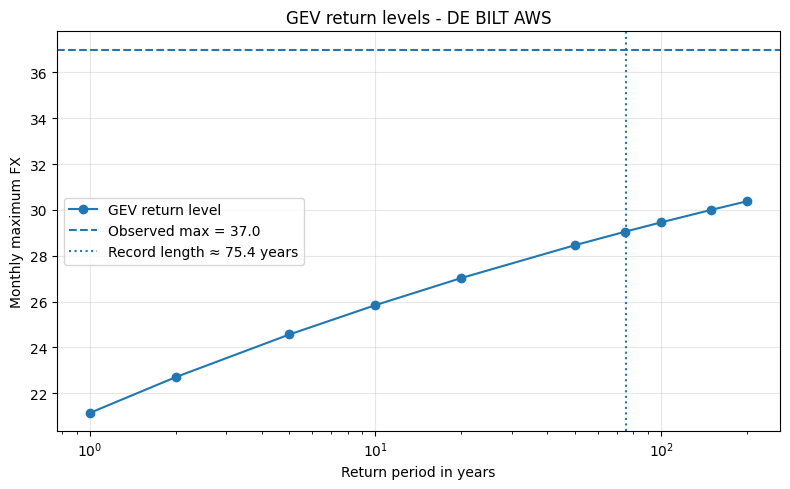

In [47]:
from scipy.stats import genextreme

c = 0.1073
loc = 14.7995
scale = 2.9527

observed_max = monthly_max["monthly_max_FX"].max()

# Return period, in monthly blocks, implied by the observed max
p = genextreme.cdf(observed_max, c, loc=loc, scale=scale)
T_months = 1 / (1 - p)
T_years = T_months / 12

print(f"Observed max: {observed_max:.2f}")
print(f"Model CDF at observed max: {p:.6f}")
print(f"Implied return period: {T_months:.1f} months = {T_years:.1f} years")
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme

c = 0.1073
loc = 14.7995
scale = 2.9527

T_years = np.array([1, 2, 5, 10, 20, 50, 75, 100, 150, 200])
T_months = T_years * 12

return_levels = genextreme.ppf(
    1 - 1 / T_months,
    c,
    loc=loc,
    scale=scale,
)

observed_max = monthly_max["monthly_max_FX"].max()
record_length_years = len(monthly_max) / 12

plt.figure(figsize=(8, 5))
plt.plot(T_years, return_levels, marker="o", label="GEV return level")
plt.axhline(observed_max, linestyle="--", label=f"Observed max = {observed_max:.1f}")
plt.axvline(record_length_years, linestyle=":", label=f"Record length ≈ {record_length_years:.1f} years")
plt.xscale("log")
plt.xlabel("Return period in years")
plt.ylabel("Monthly maximum FX")
plt.title("GEV return levels - DE BILT AWS")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

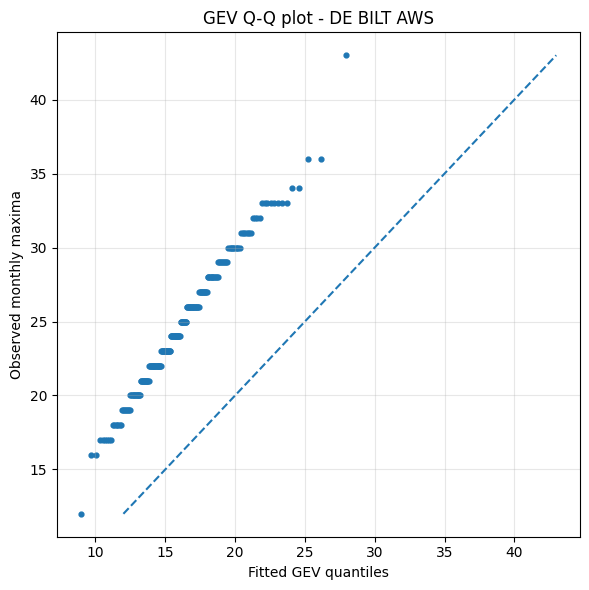

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme

x = monthly_max["monthly_max_FX"].dropna().sort_values().to_numpy()
n = len(x)

# Empirical plotting positions
p_emp = (np.arange(1, n + 1) - 0.5) / n

# Fitted GEV quantiles
c = 0.1073
loc = 14.7995
scale = 2.9527

q_fit = genextreme.ppf(p_emp, c, loc=loc, scale=scale)

plt.figure(figsize=(6, 6))
plt.scatter(q_fit, x, s=12)
plt.plot([x.min(), x.max()], [x.min(), x.max()], linestyle="--")
plt.xlabel("Fitted GEV quantiles")
plt.ylabel("Observed monthly maxima")
plt.title("GEV Q-Q plot - DE BILT AWS")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd

# Load the file
knmi_df = pd.read_csv(r"C:\Users\floris\Desktop\MSC\thesis_msc\data\knmi_daily_max_1991_2026.csv")

# Get unique station names
unique_names = knmi_df["stationname"].unique()

print("--- Unique station names in KNMI dataset ---")
for name in sorted(unique_names):
    print(name)

--- Unique station names in KNMI dataset ---
AMSTERDAM/SCHIPHOL AP
ARCEN AWS
Arcen
CABAUW TOWER AWS
CADZAND WP
Cabauw
Cadzand
DE BILT AWS
DE KOOY VK
DEELEN
De Bilt
De Kooy Airport
Deelen Airport
EINDHOVEN AP
Eindhoven Airport
GILZE RIJEN
GRONINGEN AP EELDE
Gilze-Rijen Airport
Groningen Airport Eelde
HEINO AWS
HERWIJNEN AWS
HOEK VAN HOLLAND AWS
HOOGEVEEN AWS
HUIBERTGAT WP
HUPSEL AWS
Heino
Herwijnen
Hoek van Holland
Hoogeveen
Huibertgat
Hupsel
IJMUIDEN WP
IJmuiden
LAUWERSOOG AWS
LEEUWARDEN
LELYSTAD AP
LICHTEILAND GOEREE
Lauwersoog
Leeuwarden Airport
Lelystad Airport
Lichteiland Goeree
MAASTRICHT AACHEN AP
MARKNESSE AWS
Maastricht Airport
Marknesse
NIEUW BEERTA AWS
Nieuw Beerta
OOSTERSCHELDE 4
OOSTERSCHELDE WP
Oosterschelde
ROTTERDAM GEULHAVEN
ROTTERDAM THE HAGUE AP
Rotterdam Airport
Rotterdam Geulhaven
STAVOREN AWS
Schaar
Schiphol Airport
Stavoren
TWENTHE AWS
Twenthe Airport
VLISSINGEN AWS
VOLKEL
Vlissingen
Volkel Airport
WESTDORPE AWS
Westdorpe


In [15]:
import pandas as pd

# Load files
knmi_df = pd.read_csv(r"C:\Users\floris\Desktop\MSC\thesis_msc\data\knmi_daily_max_1991_2026.csv")
meta_df = pd.read_csv("../../data/station_metadata.csv")

# 1. Extract, convert to numeric (removes leading zeros), then back to string
knmi_df["station_id"] = pd.to_numeric(knmi_df["station"].astype(str).str.extract(r"(\d{5})$")[0]).astype(str)

# 2. Do the same for metadata
meta_df["station_id"] = pd.to_numeric(meta_df["station_id"].astype(str)).astype(str)

# 3. Filter
active_stations = knmi_df["station_id"].unique()
filtered_meta = meta_df[meta_df["station_id"].isin(active_stations)]

print(f"Number of stations found: {len(filtered_meta)}")
print(filtered_meta.head())

# Save
filtered_meta.to_csv("filtered_station_metadata.csv", index=False)

Number of stations found: 33
   station_id            stationname      lat     lon  height
16       6225            IJMUIDEN WP  52.4622  4.5550    4.40
19       6235             DE KOOY VK  52.9269  4.7811    0.57
24       6240  AMSTERDAM/SCHIPHOL AP  52.3172  4.7897   -3.87
32       6260            DE BILT AWS  52.0989  5.1797    1.90
33       6267           STAVOREN AWS  52.8967  5.3833   -1.30
